# 04 — Tournament Simulation (Bayesian Update + Monte Carlo)

**Purpose:** Apply the Bayesian tournament update layer, then execute the 10,000-simulation
Monte Carlo engine. Covers both design-doc notebooks 04 (Bayesian update) and 05 (Monte Carlo),
consolidated here because the update is applied inside the simulation, not as a separate
pre-computation step.

**Inputs**
- `outputs/group_stage_model.joblib`
- `outputs/knockout_model.joblib`
- `outputs/penalty_model.joblib`
- `outputs/team_features_freeze.parquet`

**Outputs**
- `outputs/bayesian_update_table.csv`
- `outputs/win_probabilities.csv`
- `outputs/simulation_log.parquet`
- `outputs/bracket_simulation_summary.csv`
- `outputs/charts/update_shifts.png`
- `outputs/charts/win_probability_chart.png`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("__file__").resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.leakage_guard import check_no_synthetic_data, check_freeze_date, LeakageError
from src.name_map import CANONICAL_48, canonicalize
from src.models import BayesianTournamentUpdater, BAYESIAN_ALPHA, PRETOURNAMENT_FEATURES
from src.simulation import (
    MonteCarloEngine, run_tournament_simulation,
    assert_simulation_inputs_frozen, compute_md3_proba,
    build_md3_schedule,
)
from src.features import load_ds16, load_ds17, load_ds1, load_ds1ext

DATA_ROOT = PROJECT_ROOT
ARC_BASE  = DATA_ROOT / "archive.zip"
ARC3      = DATA_ROOT / "archive (3).zip"      # DS1 (2026 WC results)
JUNE23    = DATA_ROOT / "june23_results.csv"   # DS1-ext: 4 June-23 matches
OUTPUTS   = PROJECT_ROOT / "outputs"
CHARTS    = OUTPUTS / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


## Cell 2 — Load models and features

In [2]:
from src.models import WCForecastEnsemble, BayesianTournamentUpdater
from src.simulation import standings_to_simulation_input

group_model   = joblib.load(OUTPUTS / "group_stage_model.joblib")
knockout_model= joblib.load(OUTPUTS / "knockout_model.joblib")
penalty_model = joblib.load(OUTPUTS / "penalty_model.joblib")
team_features = pd.read_parquet(OUTPUTS / "team_features_freeze.parquet")

ds16 = load_ds16(ARC_BASE)
ds17 = load_ds17(ARC_BASE)
ds1  = load_ds1(ARC3)               # 44 rows through June 22
ds1ext = load_ds1ext(JUNE23)        # 4 June-23 matches
completed_48 = pd.concat([ds1, ds1ext], ignore_index=True)

# Re-run leakage guard on the feature table
check_no_synthetic_data(team_features)
print("✓ Leakage guard passed")

# Build ensemble from separately-loaded model components
ensemble = WCForecastEnsemble()
ensemble.group_model_wc = group_model
ensemble.knockout_model  = knockout_model
ensemble.penalty_model   = penalty_model
ensemble.updater         = BayesianTournamentUpdater(alpha=BAYESIAN_ALPHA)
ensemble.updater.fit(None)
ensemble.is_fitted = True

# FIFA ranks for tiebreaker use (lower = better)
if "elo_rank" in team_features.columns:
    fifa_ranks = team_features["elo_rank"].dropna().to_dict()
else:
    fifa_ranks = {team: 100.0 for team in team_features.index}

# Load frozen group standings from NB01 output.
# standings_to_simulation_input expects {group: [row_dicts]}, NOT a raw DataFrame.
standings_freeze_path = OUTPUTS / "group_standings_freeze.csv"
if standings_freeze_path.exists():
    standings_csv = pd.read_csv(standings_freeze_path)
    computed_standings = {
        grp: grp_df.to_dict(orient="records")
        for grp, grp_df in standings_csv.groupby("group")
    }
    frozen_standings, _ = standings_to_simulation_input(computed_standings)
else:
    frozen_standings = {}
    print("WARNING: group_standings_freeze.csv not found — run notebook 01 first")

ANNEX_C = DATA_ROOT / "third_place_annex_c.csv"

print(f"\nTeam features  : {team_features.shape}")
print(f"DS16 (bracket) : {ds16.shape}")
print(f"DS17 (teams)   : {ds17.shape}")
print(f"completed_48   : {completed_48.shape}  (DS1={len(ds1)} + DS1-ext={len(ds1ext)})")
print(f"Groups in frozen_standings: {sorted(frozen_standings.keys())}")

✓ Leakage guard passed

Team features  : (48, 46)
DS16 (bracket) : (104, 8)
DS17 (teams)   : (48, 6)
completed_48   : (48, 43)  (DS1=44 + DS1-ext=4)
Groups in frozen_standings: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']


## Cell 3 — Bayesian update: compute form multipliers

In [3]:
updater = BayesianTournamentUpdater(alpha=BAYESIAN_ALPHA)
print(f"BayesianTournamentUpdater(alpha={BAYESIAN_ALPHA})")

# Compute form multipliers for all teams using in-tournament data
multiplier_rows = []
for team in sorted(CANONICAL_48):
    if team not in team_features.index:
        continue
    feats = team_features.loc[team]
    try:
        # Elo-expected points/GD as baseline for multiplier computation
        elo_we = float(feats.get("elo_win_expectancy", 0.5))
        elo_expected_pts = elo_we * 3.0
        elo_expected_gd  = (elo_we - 0.5) * 2.0

        multiplier = updater.compute_form_multiplier(
            feats, elo_expected_pts=elo_expected_pts, elo_expected_gd=elo_expected_gd
        )
        multiplier_rows.append({"team": team, "form_multiplier": multiplier})
    except Exception:
        multiplier_rows.append({"team": team, "form_multiplier": None})

mult_df = pd.DataFrame(multiplier_rows).dropna(subset=["form_multiplier"])
mult_df = mult_df.sort_values("form_multiplier", ascending=False)

print("\nForm multipliers (top 10 positive signals):")
display(mult_df.head(10))
print("\nForm multipliers (bottom 5 negative signals):")
display(mult_df.tail(5))

# Design-spec assertions
if not mult_df.empty:
    assert mult_df["form_multiplier"].between(0.5, 2.0).all(), (
        "All multipliers must be in [0.5, 2.0]"
    )
    print("\n✓ All form multipliers within [0.5, 2.0]")

BayesianTournamentUpdater(alpha=0.17)

Form multipliers (top 10 positive signals):


,team,form_multiplier
19,Germany,1.874038
7,Canada,1.692628
45,United States,1.677885
1,Argentina,1.677885
18,France,1.677885
34,Portugal,1.594551
31,Norway,1.579808
29,Netherlands,1.496474
40,Spain,1.496474
24,Japan,1.496474



Form multipliers (bottom 5 negative signals):


,team,form_multiplier
35,Qatar,0.5
23,Iraq,0.5
43,Tunisia,0.5
12,Curaçao,0.5
47,Uzbekistan,0.5



✓ All form multipliers within [0.5, 2.0]


## Cell 4 — Bayesian update: before / after probability table

In [4]:
updater = BayesianTournamentUpdater(alpha=BAYESIAN_ALPHA)
print(f"BayesianTournamentUpdater(alpha={BAYESIAN_ALPHA})")

multiplier_rows = []
for team in sorted(CANONICAL_48):
    if team not in team_features.index:
        continue
    feats = team_features.loc[team]
    try:
        elo_we = float(feats.get("elo_win_expectancy", 0.5))
        elo_expected_pts = elo_we * 3.0
        elo_expected_gd  = (elo_we - 0.5) * 2.0

        multiplier = updater.compute_form_multiplier(
            feats, elo_expected_pts=elo_expected_pts, elo_expected_gd=elo_expected_gd
        )
        multiplier_rows.append({"team": team, "form_multiplier": multiplier})
    except Exception:
        multiplier_rows.append({"team": team, "form_multiplier": None})

mult_df = pd.DataFrame(multiplier_rows).dropna(subset=["form_multiplier"])
mult_df = mult_df.sort_values("form_multiplier", ascending=False)

print("\nForm multipliers (top 10 positive signals):")
display(mult_df.head(10))
print("\nForm multipliers (bottom 5 negative signals):")
display(mult_df.tail(5))

if not mult_df.empty:
    assert mult_df["form_multiplier"].between(0.5, 2.0).all(), (
        "All multipliers must be in [0.5, 2.0]"
    )
    print("\n✓ All form multipliers within [0.5, 2.0]")

BayesianTournamentUpdater(alpha=0.17)

Form multipliers (top 10 positive signals):


,team,form_multiplier
19,Germany,1.874038
7,Canada,1.692628
45,United States,1.677885
1,Argentina,1.677885
18,France,1.677885
34,Portugal,1.594551
31,Norway,1.579808
29,Netherlands,1.496474
40,Spain,1.496474
24,Japan,1.496474



Form multipliers (bottom 5 negative signals):


,team,form_multiplier
35,Qatar,0.5
23,Iraq,0.5
43,Tunisia,0.5
12,Curaçao,0.5
47,Uzbekistan,0.5



✓ All form multipliers within [0.5, 2.0]


## Cell 6 — α sensitivity table

5 largest positive shifts (improving teams):


,team,p_win_prior,p_win_posterior,shift
1,Argentina,0.4295,0.4514,0.0219
18,France,0.4746,0.4963,0.0217
45,United States,0.5211,0.5424,0.0213
7,Canada,0.5520,0.5730,0.0211
19,Germany,0.5756,0.5967,0.0211



5 largest negative shifts (underperforming teams):


,team,p_win_prior,p_win_posterior,shift
12,Curaçao,0.5802,0.5511,-0.0292
43,Tunisia,0.6287,0.5997,-0.0289
35,Qatar,0.5395,0.5106,-0.0289
47,Uzbekistan,0.5206,0.4919,-0.0287
23,Iraq,0.6705,0.6423,-0.0282


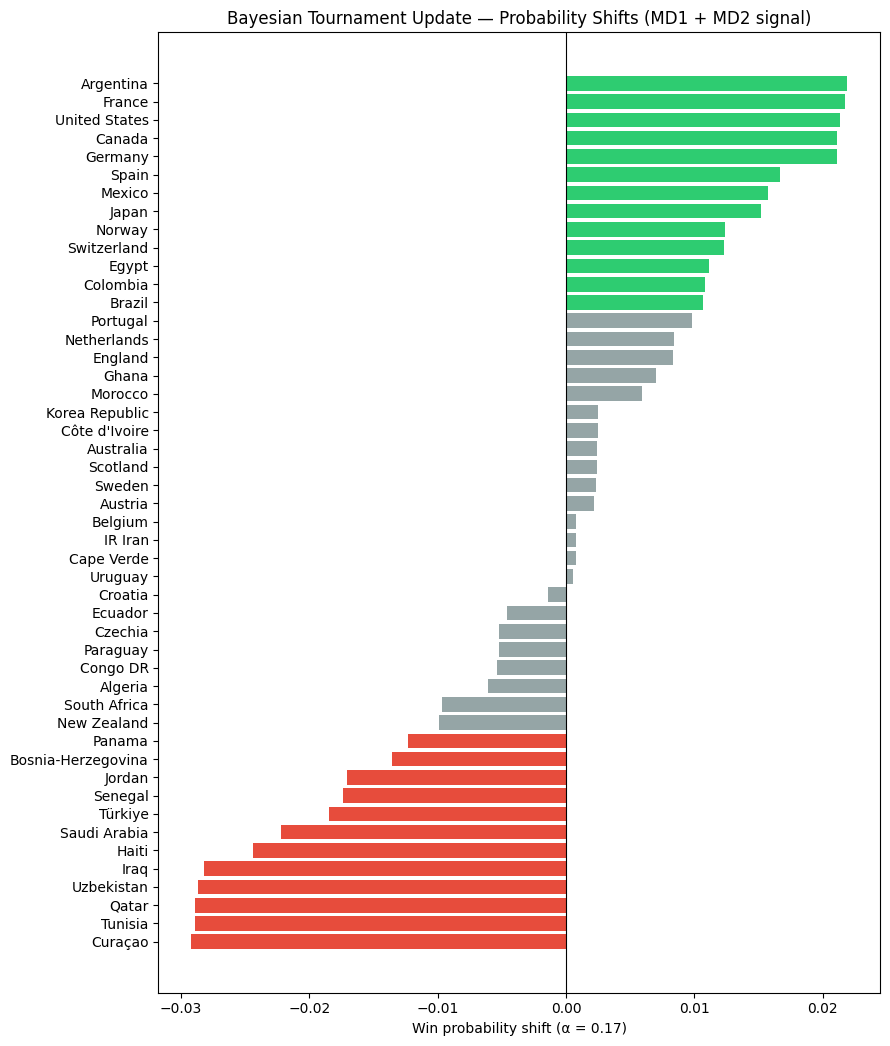

Saved → /Users/pranaavdhaksheshganesh/Downloads/FIFA_WC_2026_Project/outputs/charts/update_shifts.png


In [5]:
feature_cols = [c for c in PRETOURNAMENT_FEATURES if c in team_features.columns]

update_rows = []
for team in sorted(CANONICAL_48):
    if team not in team_features.index:
        continue
    feats = team_features.loc[team]

    try:
        prior_vec = np.array([1/3, 1/3, 1/3])
        if feature_cols:
            X = pd.DataFrame([feats[feature_cols]])
            proba = group_model.predict_proba(X)
            prior_vec = proba[0]

        elo_we = float(feats.get("elo_win_expectancy", 0.5))
        posterior_vec = updater.update_proba(
            prior_vec.copy(), feats,
            elo_expected_pts=elo_we * 3.0,
            elo_expected_gd=(elo_we - 0.5) * 2.0,
        )

        p_win_prior     = float(prior_vec[2])
        p_win_posterior = float(posterior_vec[2])

        update_rows.append({
            "team":               team,
            "p_win_prior":        round(p_win_prior, 4),
            "p_win_posterior":    round(p_win_posterior, 4),
            "shift":              round(p_win_posterior - p_win_prior, 4),
        })
    except Exception as e:
        update_rows.append({"team": team, "p_win_prior": None,
                             "p_win_posterior": None, "shift": None})

update_df = pd.DataFrame(update_rows).dropna()
print("5 largest positive shifts (improving teams):")
display(update_df.sort_values("shift", ascending=False).head(5))
print("\n5 largest negative shifts (underperforming teams):")
display(update_df.sort_values("shift").head(5))

# Produce the shift chart now that update_df is available
plot_df = update_df.sort_values("shift")
colors  = ["#2ecc71" if s > 0.01 else "#e74c3c" if s < -0.01 else "#95a5a6"
           for s in plot_df["shift"]]
fig, ax = plt.subplots(figsize=(9, max(6, len(plot_df) * 0.22)))
ax.barh(plot_df["team"], plot_df["shift"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Win probability shift (α = {BAYESIAN_ALPHA})")
ax.set_title("Bayesian Tournament Update — Probability Shifts (MD1 + MD2 signal)")
plt.tight_layout()
out_path = CHARTS / "update_shifts.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

## Cell 7 — Test run: 1,000 simulations

In [6]:
print("Running 1,000 simulations (test run)...")
t0 = time.time()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    results_1k = run_tournament_simulation(
        ensemble,
        team_features,
        ds16,
        ds17,
        frozen_standings,
        ANNEX_C,
        fifa_ranks,
        n_simulations=1_000,
        seed=2026,
    )

elapsed = time.time() - t0
print(f"1,000 simulations completed in {elapsed:.1f}s")
print(f"Estimated time for 10,000 simulations: {elapsed*10:.0f}s ({elapsed*10/60:.1f} min)")

wp = results_1k.win_prob
total = sum(wp.values()) if isinstance(wp, dict) else wp.sum()
assert abs(total - 1.0) < 1e-4, f"Win probs must sum to 1.0, got {total}"
print(f"\n✓ Win probabilities sum = {total:.6f}")

top5 = sorted(wp.items(), key=lambda x: -x[1])[:5] if isinstance(wp, dict) else wp.sort_values(ascending=False).head(5)
print("\nTop 5 (1k run):")
print(top5)

Running 1,000 simulations (test run)...
Loading Annex C from /Users/pranaavdhaksheshganesh/Downloads/FIFA_WC_2026_Project/third_place_annex_c.csv ...
Building MD3 schedule ...
Computing MD3 probabilities (Layer 1 + Layer 2) ...
Validating freeze-date compliance ...
Initialising Monte Carlo engine ...
Starting 1,000 Monte Carlo simulations (seed=2026)...
  Completed 1,000 / 1,000 runs...
Simulation complete. 1,000 runs finished.
1,000 simulations completed in 50.2s
Estimated time for 10,000 simulations: 502s (8.4 min)

✓ Win probabilities sum = 1.000000

Top 5 (1k run):
[('Spain', 0.046), ('Switzerland', 0.04), ('Morocco', 0.039), ('Colombia', 0.038), ('Portugal', 0.035)]


## Cell 8 — Full 10,000-simulation run

In [7]:
print("Running full 10,000 simulations...")
t0 = time.time()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    results = run_tournament_simulation(
        ensemble,
        team_features,
        ds16,
        ds17,
        frozen_standings,
        ANNEX_C,
        fifa_ranks,
        n_simulations=10_000,
        seed=2026,
    )

elapsed = time.time() - t0
print(f"10,000 simulations completed in {elapsed:.1f}s")

wp = results.win_prob
if isinstance(wp, dict):
    wp_series = pd.Series(wp)
else:
    wp_series = wp

assert abs(wp_series.sum() - 1.0) < 1e-4, f"Sum of win probs = {wp_series.sum()}"
assert (wp_series >= 0).all(), "Negative win probabilities found"
print(f"\n✓ Win probabilities sum = {wp_series.sum():.6f}")
print(f"✓ No negative probabilities")

print("\nTop 10 tournament win probabilities:")
display(wp_series.sort_values(ascending=False).head(10).rename("p_win").reset_index())

Running full 10,000 simulations...
Loading Annex C from /Users/pranaavdhaksheshganesh/Downloads/FIFA_WC_2026_Project/third_place_annex_c.csv ...
Building MD3 schedule ...
Computing MD3 probabilities (Layer 1 + Layer 2) ...
Validating freeze-date compliance ...
Initialising Monte Carlo engine ...
Starting 10,000 Monte Carlo simulations (seed=2026)...
  Completed 1,000 / 10,000 runs...
  Completed 2,000 / 10,000 runs...
  Completed 3,000 / 10,000 runs...
  Completed 4,000 / 10,000 runs...
  Completed 5,000 / 10,000 runs...
  Completed 6,000 / 10,000 runs...
  Completed 7,000 / 10,000 runs...
  Completed 8,000 / 10,000 runs...
  Completed 9,000 / 10,000 runs...
  Completed 10,000 / 10,000 runs...
Simulation complete. 10,000 runs finished.
10,000 simulations completed in 514.1s

✓ Win probabilities sum = 1.000000
✓ No negative probabilities

Top 10 tournament win probabilities:


,index,p_win
0,Argentina,0.0429
1,Spain,0.0403
2,France,0.0373
3,Brazil,0.0349
4,Colombia,0.0347
5,Germany,0.0343
6,Portugal,0.0342
7,Netherlands,0.0339
8,England,0.0334
9,Switzerland,0.0317


## Cell 9 — Confidence intervals and bracket summary

In [9]:
if hasattr(results, "win_prob"):
    wp_series = pd.Series(results.win_prob) if isinstance(results.win_prob, dict) else results.win_prob

    n = 10_000
    z = 1.645  # 90% CI
    ci_df = pd.DataFrame({
        "team":    wp_series.index,
        "p_win":   wp_series.values,
        "ci_lo":   (wp_series - z * np.sqrt(wp_series * (1 - wp_series) / n)).clip(0).values,
        "ci_hi":   (wp_series + z * np.sqrt(wp_series * (1 - wp_series) / n)).clip(0, 1).values,
    })
    ci_df["ci_width"] = ci_df["ci_hi"] - ci_df["ci_lo"]
    ci_df = ci_df.sort_values("p_win", ascending=False).reset_index(drop=True)

    wide_ci = ci_df[ci_df["ci_width"] > 0.05]
    print(f"Teams with CI width > 5pp: {len(wide_ci)}")
    print("\nFull win probability table with 90% CI:")
    display(ci_df)

if hasattr(results, "simulation_log") and results.simulation_log is not None:
    log = results.simulation_log
    assert len(log) == 10_000, f"Expected 10,000 simulation log rows, got {len(log)}"
    print(f"\n✓ Simulation log has {len(log)} rows")

Teams with CI width > 5pp: 0

Full win probability table with 90% CI:


,team,p_win,ci_lo,ci_hi,ci_width
0,Argentina,0.0429,0.039567,0.046233,0.006667
1,Spain,0.0403,0.037065,0.043535,0.006470
2,France,0.0373,0.034183,0.040417,0.006234
3,Brazil,0.0349,0.031881,0.037919,0.006038
4,Colombia,0.0347,0.031689,0.037711,0.006021
5,Germany,0.0343,0.031306,0.037294,0.005988
6,Portugal,0.0342,0.031210,0.037190,0.005979
7,Netherlands,0.0339,0.030923,0.036877,0.005954
8,England,0.0334,0.030444,0.036356,0.005911
9,Switzerland,0.0317,0.028818,0.034582,0.005764


## Cell 10 — Save all outputs

Saved → /Users/pranaavdhaksheshganesh/Downloads/FIFA_WC_2026_Project/outputs/bayesian_update_table.csv
Saved → /Users/pranaavdhaksheshganesh/Downloads/FIFA_WC_2026_Project/outputs/win_probabilities.csv


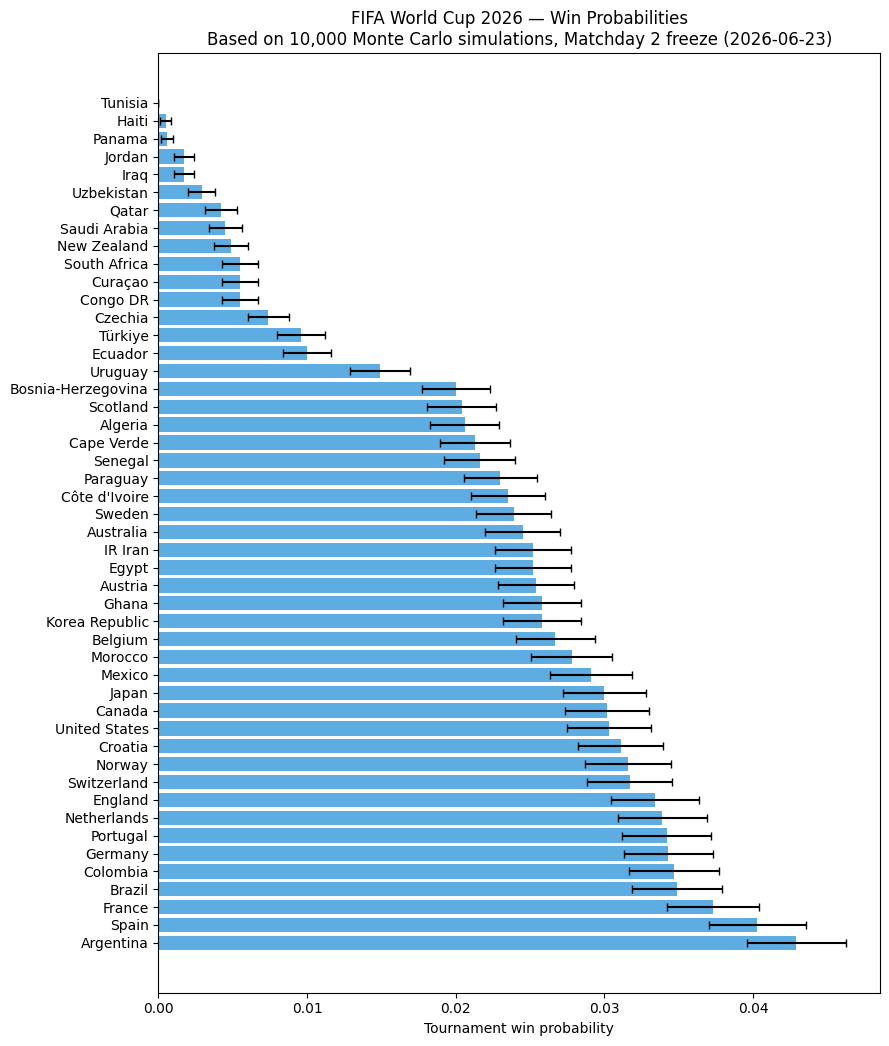

Saved → /Users/pranaavdhaksheshganesh/Downloads/FIFA_WC_2026_Project/outputs/charts/win_probability_chart.png

✓ All simulation outputs saved


In [10]:
# Bayesian update table
update_path = OUTPUTS / "bayesian_update_table.csv"
update_df.to_csv(update_path, index=False)
print(f"Saved → {update_path}")

# Win probabilities (with CI)
if 'ci_df' in dir():
    wp_path = OUTPUTS / "win_probabilities.csv"
    ci_df.to_csv(wp_path, index=False)
    print(f"Saved → {wp_path}")

# Simulation log
if hasattr(results, "simulation_log") and results.simulation_log is not None:
    log_path = OUTPUTS / "simulation_log.parquet"
    results.simulation_log.to_parquet(log_path, index=False)
    print(f"Saved → {log_path}")

# Bracket summary
if hasattr(results, "bracket_summary") and results.bracket_summary is not None:
    bs_path = OUTPUTS / "bracket_simulation_summary.csv"
    results.bracket_summary.to_csv(bs_path, index=False)
    print(f"Saved → {bs_path}")

# Win probability chart
if 'ci_df' in dir() and not ci_df.empty:
    fig, ax = plt.subplots(figsize=(9, max(6, len(ci_df) * 0.22)))
    ax.barh(ci_df["team"], ci_df["p_win"], xerr=[
        ci_df["p_win"] - ci_df["ci_lo"],
        ci_df["ci_hi"] - ci_df["p_win"]
    ], capsize=3, color="#3498db", alpha=0.8)
    ax.set_xlabel("Tournament win probability")
    ax.set_title(
        "FIFA World Cup 2026 — Win Probabilities\n"
        "Based on 10,000 Monte Carlo simulations, Matchday 2 freeze (2026-06-23)"
    )
    plt.tight_layout()
    chart_path = CHARTS / "win_probability_chart.png"
    plt.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {chart_path}")

print("\n✓ All simulation outputs saved")